In [2]:
import pandas as pd
import pickle
import numpy as np

pd.read_csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/revision_final/Fig_7/Fig_7a.csv")

,Unnamed: 0,DAPORINAD\n(NAMPT),AZD8931\n(ERBB2),BMS-754807\n(IGF1R),DABRAFENIB\n(BRAF),IMATINIB\n(MCL1),MK-2206\n(AKT1),TIVANTINIB\n(MET),ULIXERTINIB\n(MAPK1),UPROSERTIB\n(AKT1),TIVOZANIB\n(PDGFRB)
0,647V,0.208269,1.417152,0.190774,-0.563681,-0.364243,0.009684,-0.962663,0.023015,-1.710451,0.126523
1,HT1197,-0.350582,0.397002,-0.236479,-0.210034,-0.548740,-0.391227,-0.941033,-0.413017,-0.849237,-0.049506
2,J82,-1.183136,-1.092055,0.282174,-1.361780,-0.438464,-0.647332,-0.510667,-0.901613,-0.199083,0.451401
3,T24,0.281675,-0.684999,-0.908473,-0.654462,-0.928089,-0.726328,-0.778669,0.273072,-1.459090,0.166124
4,G292CLONEA141B1,-0.247516,-0.261613,0.385469,-0.484330,-1.038404,-0.747992,-0.257330,-0.599396,0.173656,-0.240327
...,...,...,...,...,...,...,...,...,...,...,...
165,MFE296,0.098511,0.921411,-1.686598,0.493149,0.890024,0.598109,0.085708,-0.223607,1.423943,0.131099
166,ESS1,0.062316,-0.536221,-0.830827,-0.584221,-0.593554,-0.593994,0.046026,0.002782,-1.281338,0.083083
167,SKUT1,0.373994,0.477134,-0.884828,-0.304017,-0.040585,-0.151834,0.541137,0.078821,1.716543,0.499549
168,MFE319,0.810601,1.137978,-1.257980,0.662691,0.040877,-0.435779,-1.012849,-1.471620,1.381147,-0.205112


--- Setting up environment and paths ---
Loading global lineage data...
Lineage data loaded successfully.

--- Loading models and calculating benefit scores ---
   Loading expression data from: /home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Exp.csv
   Processed DAPORINAD: 650 cells, 198 genes.
   Processed AZD8931: 491 cells, 171 genes.
   Processed BMS-754807: 677 cells, 200 genes.
   Processed DABRAFENIB: 592 cells, 201 genes.
   Processed IMATINIB: 592 cells, 175 genes.
   Processed MK-2206: 665 cells, 200 genes.
   Processed TIVANTINIB: 267 cells, 200 genes.
   Processed ULIXERTINIB: 510 cells, 197 genes.
   Processed UPROSERTIB: 511 cells, 200 genes.
   Processed TIVOZANIB: 675 cells, 201 genes.

Merging data into a single matrix...
Final Matrix Shape: (170, 10) (Cell Lines x Drugs)
Sorting data by lineage...
Generating heatmap...


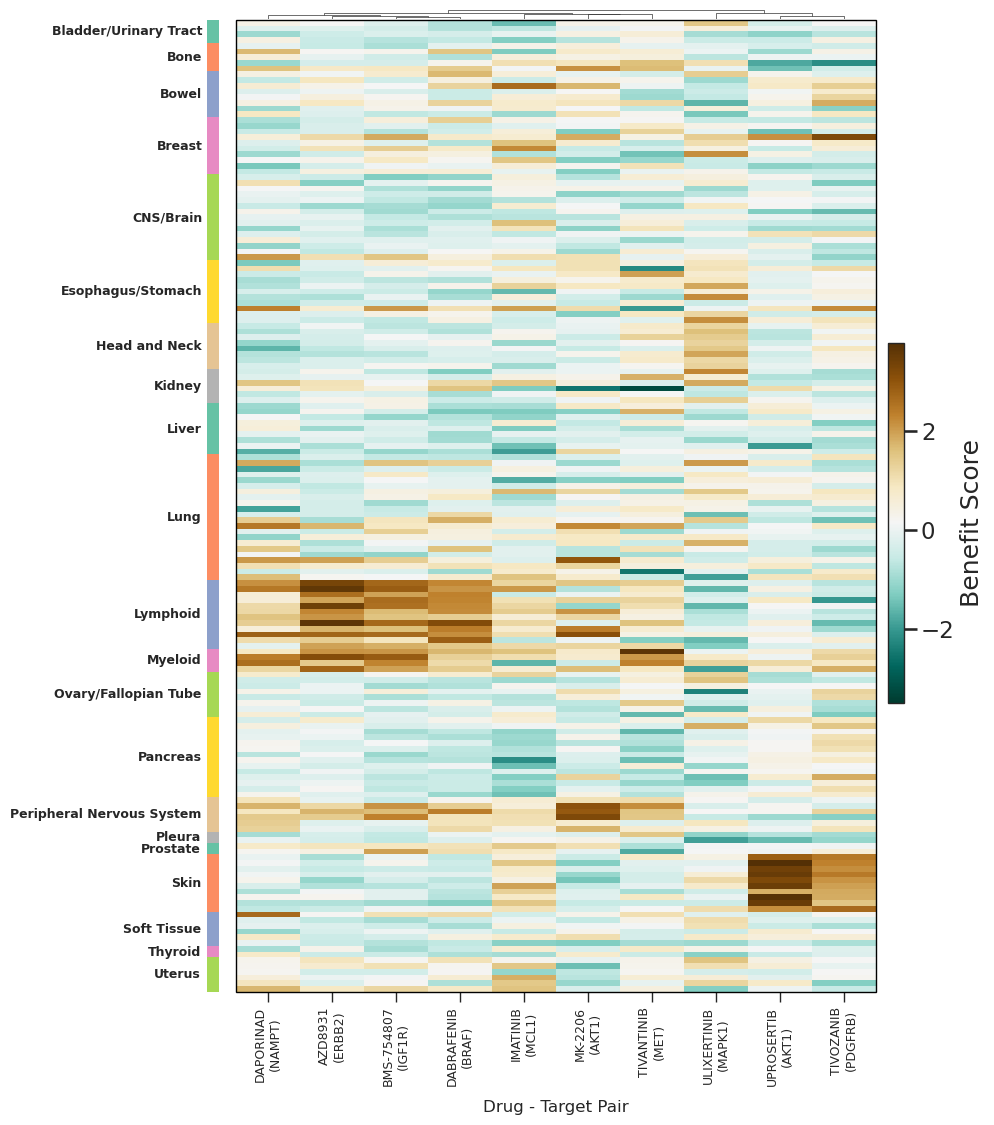

Done.


In [3]:
import os
import pandas as pd
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, Normalize
# === 1. Setup Environment and Paths ===
print("--- Setting up environment and paths ---")
# --- Configure Matplotlib ---
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'DejaVu Sans'
sns.set(style="white", context="talk", font_scale=1.0)
# --- Input/Output Directories ---
# Base Directory for Models
BASE_MODELS_DIR = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/optuna_models"
# SPECIFIC MODEL FILE FOR DAPORINAD_NAMPT
DAPORINAD_NAMPT_MODEL = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna/DAPORINAD_NAMPT_forgeModel_optuna100_321456.pkl"
# Path to Global Data Files
MODEL_LINEAGE_PATH = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Model_24_Q4.csv"
# --- 2. Load Global Lineage Data ---
print("Loading global lineage data...")
try:
    model_lineage_df = pd.read_csv(MODEL_LINEAGE_PATH)
    lineage_map = model_lineage_df.set_index('StrippedCellLineName')['OncotreeLineage'].to_dict()
    print("Lineage data loaded successfully.")
except FileNotFoundError:
    print(f"Error: Lineage file not found at {MODEL_LINEAGE_PATH}")
    exit()
# --- Define the specific drug-target pairs to analyze ---
specific_pairs = [
    {'drug_name': 'DAPORINAD', 'target': 'NAMPT'}, 
    {'drug_name': 'AZD8931', 'target': 'ERBB2'},
    {'drug_name': 'BMS-754807', 'target': 'IGF1R'}, 
    {'drug_name': 'DABRAFENIB', 'target': 'BRAF'},
    {'drug_name': 'IMATINIB', 'target': 'MCL1'}, 
    {'drug_name': 'MK-2206', 'target': 'AKT1'},
    {'drug_name': 'TIVANTINIB', 'target': 'MET'}, 
    {'drug_name': 'ULIXERTINIB', 'target': 'MAPK1'}, 
    {'drug_name': 'UPROSERTIB', 'target': 'AKT1'}, 
    {'drug_name': 'TIVOZANIB', 'target': 'PDGFRB'}
]
# --- 3. Load Models, Data, and Calculate Benefit Scores ---
print("\n--- Loading models and calculating benefit scores ---")
loaded_scores = {}
cached_exp_dfs = {}
for pair in specific_pairs:
    drug_name = pair['drug_name']
    target_name = pair['target']
    
    # Check if this is the DAPORINAD_NAMPT pair - use special model file
    if drug_name == 'DAPORINAD' and target_name == 'NAMPT':
        model_path = DAPORINAD_NAMPT_MODEL
    else:
        # Construct filename for other pairs
        model_filename = f"{drug_name}_{target_name}_forgeModel_optuna100.pkl"
        model_path = os.path.join(BASE_MODELS_DIR, model_filename)
    
    pair_label = f"{drug_name}\n({target_name})"
    if not os.path.exists(model_path):
        print(f"--> WARNING: Model not found: {model_path}. Skipping.")
        continue
    try:
        # 1. Load the Pickle Object
        with open(model_path, "rb") as f:
            model = pickle.load(f)
        
        # 2. Get the specific gene list from the model attribute
        try:
            hcg_list = model.hcg_list
        except AttributeError:
            print(f"--> Error: Model for {drug_name} does not have 'hcg_list' attribute.")
            continue
        # 3. Load Expression Data (with caching based on file path)
        if model.exp_path not in cached_exp_dfs:
            print(f"   Loading expression data from: {model.exp_path}")
            full_exp_df = pd.read_csv(model.exp_path, header=0, index_col=0)
            full_exp_df = full_exp_df[~full_exp_df.index.duplicated(keep='first')]
            cached_exp_dfs[model.exp_path] = full_exp_df
        else:
            full_exp_df = cached_exp_dfs[model.exp_path]
        # 4. Determine Common Cell Lines
        model_cells = set(model.train_cellLines) | set(model.test_cellLines)
        common_cells = sorted(list(model_cells & set(full_exp_df.index)))
        
        if not common_cells:
            print(f"--> WARNING: No common cell lines for {drug_name}.")
            continue
            
        # 5. Prepare Matrices
        try:
            E_subset = full_exp_df.loc[common_cells, hcg_list]
            G = E_subset.to_numpy()
        except KeyError as e:
            print(f"--> Missing genes in expression data for {drug_name}: {e}")
            continue
        
        # Verify shapes
        if G.shape[1] != model.W.shape[0]:
            print(f"--> Shape mismatch for {drug_name}. G columns: {G.shape[1]}, W rows: {model.W.shape[0]}. Skipping.")
            continue
        # 6. Calculate Latent Factors (Z) and Benefit Score
        Z = G @ model.W
        delta_h = model.hD - model.hI
        benefit_vector = Z @ delta_h
        
        if benefit_vector.ndim > 1:
            benefit_vector = benefit_vector.flatten()
            
        loaded_scores[pair_label] = pd.Series(benefit_vector, index=common_cells)
        print(f"   Processed {drug_name}: {len(common_cells)} cells, {G.shape[1]} genes.")
    except Exception as e:
        print(f"--> ERROR processing {drug_name}: {e}")
# --- 4. Create the Benefit Score Matrix ---
if not loaded_scores:
    print("\nNo models were successfully processed. Aborting."); exit()
print("\nMerging data into a single matrix...")
benefit_matrix = pd.DataFrame(loaded_scores)
benefit_matrix = benefit_matrix.dropna()
print(f"Final Matrix Shape: {benefit_matrix.shape} (Cell Lines x Drugs)")
# --- Z-score the benefit scores column-wise ---
benefit_matrix = benefit_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
# --- 5. Sort Matrix by Lineage ---
print("Sorting data by lineage...")
benefit_matrix['lineage'] = benefit_matrix.index.map(lineage_map).fillna('Unknown')
benefit_matrix.sort_values(by='lineage', inplace=True)
# Colors
sorted_lineages = benefit_matrix['lineage']
unique_lineages = sorted(sorted_lineages.unique())
palette = sns.color_palette("Set2", len(unique_lineages))
lineage_colors = dict(zip(unique_lineages, palette))
row_colors = sorted_lineages.map(lineage_colors).to_frame(name="Lineage")
matrix_for_plotting = benefit_matrix.drop(columns=['lineage'])
# --- 6. Generate the Heatmap ---
print("Generating heatmap...")
cmap = 'BrBG_r'
g = sns.clustermap(
    matrix_for_plotting,
    row_cluster=False, 
    col_cluster=True, 
    method='ward',
    cmap=cmap, 
    center=0, 
    row_colors=row_colors,
    figsize=(8, 12), 
    dendrogram_ratio=(.1, .01),
    cbar_pos=None, 
    yticklabels=False, 
    xticklabels=True
)
# Rasterize heatmap for PDF performance
g.ax_heatmap.collections[0].set_rasterized(True)
# --- Custom Annotation Logic ---
g.ax_row_colors.set_visible(True)
g.ax_row_colors.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
g.ax_row_colors.spines['left'].set_visible(False)
g.ax_row_colors.spines['bottom'].set_visible(False)
# Calculate label positions
lineage_positions = sorted_lineages.to_frame().reset_index().groupby('lineage').agg(
    start=('index', 'first'),
    end=('index', 'last')
)
for lineage, pos in lineage_positions.iterrows():
    try:
        start_idx = matrix_for_plotting.index.get_loc(pos['start'])
        end_idx = matrix_for_plotting.index.get_loc(pos['end'])
        
        if isinstance(start_idx, slice): start_idx = start_idx.start
        if isinstance(end_idx, slice): end_idx = end_idx.stop - 1
            
        center_pos = (start_idx + end_idx + 1) / 2
        total_rows = len(matrix_for_plotting)
        y_pos_normalized = (total_rows - center_pos) / total_rows
        
        bbox = g.ax_row_colors.get_position()
        
        orig_pos = g.ax_row_colors.get_position()
        new_pos = [orig_pos.x0 - 0.0001, orig_pos.y0, 0.015, orig_pos.height]
        g.ax_row_colors.set_position(new_pos)
        
        final_y = bbox.y0 + y_pos_normalized * bbox.height
        
        g.fig.text(
            bbox.x0 - 0.008, 
            final_y,
            lineage,
            ha='right', 
            va='center', 
            fontsize=9,
            fontweight='bold'
        )
    except Exception as e:
        pass
# --- Custom Colorbar (Right Side) ---
cbar_ax = g.fig.add_axes([0.98, 0.40, 0.02, 0.3])
norm = plt.Normalize(vmin=matrix_for_plotting.values.min(), vmax=matrix_for_plotting.values.max())
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label='Benefit Score')
cbar_ax.yaxis.set_label_position('right')
cbar_ax.yaxis.set_ticks_position('right')
for spine in cbar_ax.spines.values(): spine.set_linewidth(1)
# --- Standard Aesthetics ---
g.ax_heatmap.set_xlabel("Drug - Target Pair", fontsize=12, labelpad=10)
g.ax_heatmap.set_ylabel("")
for tick_label in g.ax_heatmap.get_xticklabels():
    tick_label.set_rotation(90)
    tick_label.set_horizontalalignment('center')
    tick_label.set_fontsize(9)
g.ax_heatmap.set_yticks([])
g.ax_heatmap.tick_params(axis='y', length=0)
# --- Explicit X-axis ticks ---
ax = g.ax_heatmap
n_cols = matrix_for_plotting.shape[1]
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(
    matrix_for_plotting.columns,
    rotation=90,
    ha="center",
    fontsize=9
)
ax.tick_params(axis='x', bottom=True, top=False, length=7, width=1)
# --- Add Black Border ---
x0, y0, width, height = g.ax_heatmap.get_position().bounds
rect = patches.Rectangle(
    (x0, y0), width, height,
    linewidth=1, edgecolor='black', facecolor='none',
    transform=g.fig.transFigure, zorder=10
)
g.fig.patches.append(rect)
#plt.savefig('/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Fig5/Benefit_score_heatmap.pdf', dpi=600, bbox_inches='tight')
plt.show()
print("Done.")

In [4]:
# ==========================================
# 7. Top 3 Enriched Lineages per Drug-Target
# ==========================================

print("\n--- Calculating Top 3 Enriched Lineages per Drug-Target Pair ---")

results = {}

# Loop over each drug-target column
for col in matrix_for_plotting.columns:
    
    temp_df = pd.DataFrame({
        'benefit': matrix_for_plotting[col],
        'lineage': benefit_matrix['lineage']
    }).dropna()
    
    # Mean benefit per lineage
    lineage_scores = (
        temp_df
        .groupby('lineage')['benefit']
        .mean()
        .sort_values(ascending=False)
    )
    
    # Get top 3
    top3 = lineage_scores.head(3)
    
    results[col] = top3
    
    print(f"\n🔹 {col}")
    print(top3)


--- Calculating Top 3 Enriched Lineages per Drug-Target Pair ---

🔹 DAPORINAD
(NAMPT)
lineage
Myeloid                      1.676042
Lymphoid                     1.184335
Peripheral Nervous System    1.183573
Name: benefit, dtype: float64

🔹 AZD8931
(ERBB2)
lineage
Head and Neck        1.320549
Esophagus/Stomach    0.901136
Kidney               0.712755
Name: benefit, dtype: float64

🔹 BMS-754807
(IGF1R)
lineage
Peripheral Nervous System    2.030888
Bone                         0.829546
Lymphoid                     0.781039
Name: benefit, dtype: float64

🔹 DABRAFENIB
(BRAF)
lineage
Skin        3.104815
Myeloid     0.440293
Pancreas    0.168618
Name: benefit, dtype: float64

🔹 IMATINIB
(MCL1)
lineage
Myeloid     2.236462
Lymphoid    2.066761
Prostate    1.331944
Name: benefit, dtype: float64

🔹 MK-2206
(AKT1)
lineage
Lymphoid                     2.496309
Myeloid                      2.300679
Peripheral Nervous System    0.561435
Name: benefit, dtype: float64

🔹 TIVANTINIB
(MET)
lineage


In [6]:
# Convert to DataFrame for export
top3_df = pd.DataFrame(results).T

print("\nFinal Top 3 Lineages Table:")
top3_df

# Save if needed
#top3_df.to_csv("top3_lineages_per_drug_target.csv")


Final Top 3 Lineages Table:


lineage,Bone,Esophagus/Stomach,Head and Neck,Kidney,Lymphoid,Myeloid,Pancreas,Peripheral Nervous System,Prostate,Skin,Uterus
DAPORINAD\n(NAMPT),NaN,NaN,NaN,NaN,1.184335,1.676042,NaN,1.183573,NaN,NaN,NaN
AZD8931\n(ERBB2),NaN,0.901136,1.320549,0.712755,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BMS-754807\n(IGF1R),0.829546,NaN,NaN,NaN,0.781039,NaN,NaN,2.030888,NaN,NaN,NaN
DABRAFENIB\n(BRAF),NaN,NaN,NaN,NaN,NaN,0.440293,0.168618,NaN,NaN,3.104815,NaN
IMATINIB\n(MCL1),NaN,NaN,NaN,NaN,2.066761,2.236462,NaN,NaN,1.331944,NaN,NaN
MK-2206\n(AKT1),NaN,NaN,NaN,NaN,2.496309,2.300679,NaN,0.561435,NaN,NaN,NaN
TIVANTINIB\n(MET),NaN,NaN,NaN,NaN,2.174814,1.298853,NaN,1.065431,NaN,NaN,NaN
ULIXERTINIB\n(MAPK1),NaN,NaN,NaN,NaN,NaN,1.184070,0.693523,NaN,NaN,2.063631,NaN
UPROSERTIB\n(AKT1),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.016605,0.943044,0.808654
TIVOZANIB\n(PDGFRB),0.745473,NaN,NaN,NaN,NaN,2.165232,NaN,1.020307,NaN,NaN,NaN


In [2]:
import os
import pandas as pd
import pickle
import numpy as np
BASE_MODELS_DIR = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/optuna_models"
DAPORINAD_NAMPT_MODEL = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Models/multiSeed_optuna/DAPORINAD_NAMPT_forgeModel_optuna100_321456.pkl"
MODEL_LINEAGE_PATH = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Model_24_Q4.csv"
OUTPUT_DIR = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data"
specific_pairs = [
    {'drug_name': 'DAPORINAD', 'target': 'NAMPT'},
    {'drug_name': 'AZD8931', 'target': 'ERBB2'},
    {'drug_name': 'BMS-754807', 'target': 'IGF1R'},
    {'drug_name': 'DABRAFENIB', 'target': 'BRAF'},
    {'drug_name': 'IMATINIB', 'target': 'MCL1'},
    {'drug_name': 'MK-2206', 'target': 'AKT1'},
    {'drug_name': 'TIVANTINIB', 'target': 'MET'},
    {'drug_name': 'ULIXERTINIB', 'target': 'MAPK1'},
    {'drug_name': 'UPROSERTIB', 'target': 'AKT1'},
    {'drug_name': 'TIVOZANIB', 'target': 'PDGFRB'},
]
print("Loading lineage data...")
model_lineage_df = pd.read_csv(MODEL_LINEAGE_PATH)
lineage_map = model_lineage_df.set_index('StrippedCellLineName')['OncotreeLineage'].to_dict()
loaded_scores = {}
cached_exp_dfs = {}
for pair in specific_pairs:
    drug_name = pair['drug_name']
    target_name = pair['target']
    if drug_name == 'DAPORINAD' and target_name == 'NAMPT':
        model_path = DAPORINAD_NAMPT_MODEL
    else:
        model_filename = f"{drug_name}_{target_name}_forgeModel_optuna100.pkl"
        model_path = os.path.join(BASE_MODELS_DIR, model_filename)
    pair_label = f"{drug_name}\n({target_name})"
    if not os.path.exists(model_path):
        print(f"--> WARNING: Model not found: {model_path}. Skipping.")
        continue
    try:
        with open(model_path, "rb") as f:
            model = pickle.load(f)
        hcg_list = model.hcg_list
        if model.exp_path not in cached_exp_dfs:
            full_exp_df = pd.read_csv(model.exp_path, header=0, index_col=0)
            full_exp_df = full_exp_df[~full_exp_df.index.duplicated(keep='first')]
            cached_exp_dfs[model.exp_path] = full_exp_df
        else:
            full_exp_df = cached_exp_dfs[model.exp_path]
        model_cells = set(model.train_cellLines) | set(model.test_cellLines)
        common_cells = sorted(list(model_cells & set(full_exp_df.index)))
        if not common_cells:
            continue
        E_subset = full_exp_df.loc[common_cells, hcg_list]
        G = E_subset.to_numpy()
        if G.shape[1] != model.W.shape[0]:
            continue
        Z = G @ model.W
        delta_h = model.hD - model.hI
        benefit_vector = Z @ delta_h
        if benefit_vector.ndim > 1:
            benefit_vector = benefit_vector.flatten()
        loaded_scores[pair_label] = pd.Series(benefit_vector, index=common_cells)
        print(f"   Processed {drug_name}: {len(common_cells)} cells, {G.shape[1]} genes.")
    except Exception as e:
        print(f"--> ERROR processing {drug_name}: {e}")
if not loaded_scores:
    print("No models processed. Aborting.")
    exit()
print("\nMerging data into benefit matrix...")
benefit_matrix = pd.DataFrame(loaded_scores)
benefit_matrix = benefit_matrix.dropna()
print(f"Matrix Shape: {benefit_matrix.shape}")
benefit_matrix = benefit_matrix.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
benefit_matrix['lineage'] = benefit_matrix.index.map(lineage_map).fillna('Unknown')
benefit_matrix.sort_values(by='lineage', inplace=True)
sorted_lineages = benefit_matrix['lineage']
unique_lineages = sorted(sorted_lineages.unique())
matrix_for_plotting = benefit_matrix.drop(columns=['lineage'])
# === Save matrix_for_plotting as Fig_7a.csv ===
fig7a_path = os.path.join(OUTPUT_DIR, "Fig_7a.csv")
matrix_for_plotting.to_csv(fig7a_path)
print(f"\nFig_7a.csv saved to: {fig7a_path}")
# === Calculate enrichment for all lineages ===
print("\n=== Calculating lineage enrichment ===")
lineage_enrichment = {}
for lineage in unique_lineages:
    lineage_mask = benefit_matrix['lineage'] == lineage
    non_lineage_mask = benefit_matrix['lineage'] != lineage
    lineage_mean = matrix_for_plotting[lineage_mask].mean()
    non_lineage_mean = matrix_for_plotting[non_lineage_mask].mean()
    enrichment = lineage_mean - non_lineage_mean
    top3 = enrichment.sort_values(ascending=False).head(3)
    lineage_enrichment[lineage] = top3
    print(f"\n{lineage} - Top 3:")
    for pair_label, score in top3.items():
        print(f"  {pair_label.replace(chr(10), ' ')}: {score:.4f}")
# === Save top 3 lineage enrichment as CSV ===
top3_rows = []
for lineage, top3_series in lineage_enrichment.items():
    for rank, (pair_label, score) in enumerate(top3_series.items(), 1):
        top3_rows.append({
            'Lineage': lineage,
            'Rank': rank,
            'Drug_Target_Pair': pair_label.replace('\n', ' '),
            'Enrichment_Score': score
        })
top3_df = pd.DataFrame(top3_rows)
top3_csv_path = os.path.join(OUTPUT_DIR, "top3_lineage_enrichment.csv")
top3_df.to_csv(top3_csv_path, index=False)
print(f"\ntop3_lineage_enrichment.csv saved to: {top3_csv_path}")

Loading lineage data...
   Processed DAPORINAD: 650 cells, 198 genes.
   Processed AZD8931: 491 cells, 171 genes.
   Processed BMS-754807: 677 cells, 200 genes.
   Processed DABRAFENIB: 592 cells, 201 genes.
   Processed IMATINIB: 592 cells, 175 genes.
   Processed MK-2206: 665 cells, 200 genes.
   Processed TIVANTINIB: 267 cells, 200 genes.
   Processed ULIXERTINIB: 510 cells, 197 genes.
   Processed UPROSERTIB: 511 cells, 200 genes.
   Processed TIVOZANIB: 675 cells, 201 genes.

Merging data into benefit matrix...
Matrix Shape: (170, 10)

Fig_7a.csv saved to: /home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Data/Fig_7a.csv

=== Calculating lineage enrichment ===

Bladder/Urinary Tract - Top 3:
  TIVOZANIB (PDGFRB): 0.1778
  AZD8931 (ERBB2): 0.0095
  BMS-754807 (IGF1R): -0.1720

Bone - Top 3:
  BMS-754807 (IGF1R): 0.8547
  TIVOZANIB (PDGFRB): 0.7681
  DAPORINAD (NAMPT): 0.4211

Bowel - Top 3:
  ULIXERTINIB (MAPK1): 0.5683
  BM